In [38]:
# If needed in a fresh environment, install the core packages first:
# !pip install torch lightning pytorch-forecasting scikit-learn matplotlib pandas numpy


In [39]:
from pathlib import Path
import json
import random
import shutil

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from lightning.pytorch import Trainer, seed_everything
from lightning.pytorch.callbacks import Callback, EarlyStopping, ModelCheckpoint
from lightning.pytorch.loggers import CSVLogger
from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
from pytorch_forecasting.metrics import RMSE
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import WeightedRandomSampler

SEED = 42
seed_everything(SEED, workers=True)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


Seed set to 42


In [40]:
DATA_PATH = Path("combined_scaled_battery_data.csv")
WINDOW_SIZE = 10
MAX_PREDICTION_LENGTH = 1
BATCH_SIZE = 64
MAX_EPOCHS = 20
PATIENCE = 5
NASA_WEIGHT = 12.0
USE_SOURCE_BALANCED_SAMPLER = True
VAL_MONITOR = "val_balanced_source_norm_rmse"

LEARNING_RATE = 0.03
HIDDEN_SIZE = 16
ATTENTION_HEAD_SIZE = 2
DROPOUT = 0.1
HIDDEN_CONTINUOUS_SIZE = 8

CHECKPOINT_DIR = Path("model_checkpoints/demo_tft_transformer_balanced")
STABLE_CHECKPOINT_PATH = Path("model_checkpoints/demo_tft_transformer_balanced.ckpt")
METRICS_PATH = Path("model_checkpoints/demo_tft_transformer_balanced_metrics.json")
PREDICTIONS_PATH = Path("model_checkpoints/demo_tft_transformer_balanced_predictions.csv")
PLOT_PATH = Path("figures/demo_tft_transformer_balanced_pred_vs_true.png")
LOG_DIR = Path("lightning_logs")

FEATURE_RENAME = {
    "Cycle_Index": "time_idx",
    "Discharge Time (s)": "discharge_time",
    "Decrement 3.6-3.4V (s)": "decrement_36_34",
    "Max. Voltage Dischar. (V)": "max_voltage_discharge",
    "Min. Voltage Charg. (V)": "min_voltage_charge",
    "Time at 4.15V (s)": "time_at_415",
    "Time constant current (s)": "time_constant_current",
    "Charging time (s)": "charging_time",
    "RUL": "target",
}

UNKNOWN_REALS = [
    "discharge_time",
    "decrement_36_34",
    "max_voltage_discharge",
    "min_voltage_charge",
    "time_at_415",
    "time_constant_current",
    "charging_time",
]


In [41]:
def load_data(path: Path, seed: int):
    df = pd.read_csv(path).rename(columns=FEATURE_RENAME).reset_index(drop=True)
    df["battery_id"] = (df["time_idx"] == 1).cumsum() - 1
    df = df.sort_values(["battery_id", "time_idx"]).reset_index(drop=True)
    df["battery_id"] = df["battery_id"].astype(str)
    df["time_idx"] = df["time_idx"].astype(int)
    df["Is_NASA"] = df["Is_NASA"].astype(float)
    df["sample_weight"] = np.where(df["Is_NASA"] == 1.0, NASA_WEIGHT, 1.0).astype(float)

    battery_ids = df["battery_id"].unique()
    train_ids, test_ids = train_test_split(battery_ids, test_size=0.2, random_state=seed)
    train_ids, val_ids = train_test_split(train_ids, test_size=0.2, random_state=seed)

    train_df = df[df["battery_id"].isin(train_ids)].copy()
    val_df = df[df["battery_id"].isin(val_ids)].copy()
    test_df = df[df["battery_id"].isin(test_ids)].copy()
    return train_df, val_df, test_df


train_df, val_df, test_df = load_data(DATA_PATH, SEED)
print("Rows - train/val/test:", len(train_df), len(val_df), len(test_df))
print("Batteries - train/val/test:", train_df["battery_id"].nunique(), val_df["battery_id"].nunique(), test_df["battery_id"].nunique())
print("Test source counts:", test_df["Is_NASA"].value_counts().sort_index().to_dict())
print("NASA sample weight:", NASA_WEIGHT)


Rows - train/val/test: 13216 1701 2741
Batteries - train/val/test: 30 8 10
Test source counts: {0.0: 2120, 1.0: 621}
NASA sample weight: 12.0


In [42]:
def build_datasets(train_df, val_df, test_df, max_encoder_length: int):
    standard_scalers = {col: StandardScaler() for col in ["Is_NASA", "time_idx", *UNKNOWN_REALS]}
    training = TimeSeriesDataSet(
        train_df,
        time_idx="time_idx",
        target="target",
        group_ids=["battery_id"],
        weight="sample_weight",
        min_encoder_length=1,
        max_encoder_length=max_encoder_length,
        min_prediction_length=MAX_PREDICTION_LENGTH,
        max_prediction_length=MAX_PREDICTION_LENGTH,
        static_categoricals=[],
        static_reals=["Is_NASA"],
        time_varying_known_reals=["time_idx"],
        time_varying_unknown_reals=UNKNOWN_REALS,
        add_relative_time_idx=True,
        add_target_scales=False,
        add_encoder_length=True,
        target_normalizer=None,
        scalers=standard_scalers,
        allow_missing_timesteps=True,
    )
    validation = TimeSeriesDataSet.from_dataset(training, val_df, predict=False, stop_randomization=True)
    test = TimeSeriesDataSet.from_dataset(training, test_df, predict=False, stop_randomization=True)
    return training, validation, test


def source_sample_weights(dataset: TimeSeriesDataSet, source_df: pd.DataFrame):
    source_by_battery = source_df[["battery_id", "Is_NASA"]].drop_duplicates().copy()
    source_by_battery["battery_id"] = source_by_battery["battery_id"].astype(str)
    sample_sources = dataset.decoded_index[["battery_id"]].copy()
    sample_sources["battery_id"] = sample_sources["battery_id"].astype(str)
    sample_sources = sample_sources.merge(source_by_battery, on="battery_id", how="left")
    if sample_sources["Is_NASA"].isna().any():
        raise ValueError("Could not map every dataset sample to a source flag.")

    source_counts = sample_sources["Is_NASA"].value_counts().to_dict()
    weights = sample_sources["Is_NASA"].map(lambda source: 1.0 / source_counts[source]).astype(float)
    weights = weights / weights.mean()
    return torch.as_tensor(weights.to_numpy(), dtype=torch.double), source_counts


training, validation, test = build_datasets(train_df, val_df, test_df, WINDOW_SIZE)
if USE_SOURCE_BALANCED_SAMPLER:
    train_sample_weights, train_source_window_counts = source_sample_weights(training, train_df)
    train_sampler = WeightedRandomSampler(
        weights=train_sample_weights,
        num_samples=len(train_sample_weights),
        replacement=True,
    )
    train_loader = training.to_dataloader(train=False, batch_size=BATCH_SIZE, num_workers=0, sampler=train_sampler)
else:
    train_sample_weights = None
    train_source_window_counts = None
    train_loader = training.to_dataloader(train=True, batch_size=BATCH_SIZE, num_workers=0)

val_loader = validation.to_dataloader(train=False, batch_size=BATCH_SIZE, num_workers=0)
test_loader = test.to_dataloader(train=False, batch_size=BATCH_SIZE, num_workers=0)

print("TimeSeriesDataSet samples - train/val/test:", len(training), len(validation), len(test))
print("Source-balanced sampler enabled:", USE_SOURCE_BALANCED_SAMPLER)
print("Training window counts by source:", train_source_window_counts)
print("DataLoader batches - train/val/test:", len(train_loader), len(val_loader), len(test_loader))


TimeSeriesDataSet samples - train/val/test: 13821 1794 2899
Source-balanced sampler enabled: True
Training window counts by source: {0.0: 12140, 1.0: 1681}
DataLoader batches - train/val/test: 216 29 46


In [ ]:
def build_tft(training: TimeSeriesDataSet) -> TemporalFusionTransformer:
    return TemporalFusionTransformer.from_dataset(
        training,
        learning_rate=LEARNING_RATE,
        hidden_size=HIDDEN_SIZE,
        attention_head_size=ATTENTION_HEAD_SIZE,
        dropout=DROPOUT,
        hidden_continuous_size=HIDDEN_CONTINUOUS_SIZE,
        output_size=1,
        loss=RMSE(),
        reduce_on_plateau_patience=3,
    )


model = build_tft(training)
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f"Trainable parameters: {num_params:,}")

TemporalFusionTransformer(
  	"attention_head_size":               2
  	"categorical_groups":                {}
  	"causal_attention":                  True
  	"dataset_parameters":                {'time_idx': 'time_idx', 'target': 'target', 'group_ids': ['battery_id'], 'weight': 'sample_weight', 'max_encoder_length': 10, 'min_encoder_length': 1, 'min_prediction_idx': np.int64(1), 'min_prediction_length': 1, 'max_prediction_length': 1, 'static_categoricals': [], 'static_reals': ['Is_NASA'], 'time_varying_known_categoricals': None, 'time_varying_known_reals': ['time_idx'], 'time_varying_unknown_categoricals': None, 'time_varying_unknown_reals': ['discharge_time', 'decrement_36_34', 'max_voltage_discharge', 'min_voltage_charge', 'time_at_415', 'time_constant_current', 'charging_time'], 'variable_groups': None, 'constant_fill_strategy': None, 'allow_missing_timesteps': True, 'lags': None, 'add_relative_time_idx': True, 'add_target_scales': False, 'add_encoder_length': True, 'target_normal

/opt/anaconda3/envs/mlp/lib/python3.10/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/opt/anaconda3/envs/mlp/lib/python3.10/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.


In [44]:
def move_to_device(batch, device):
    if isinstance(batch, torch.Tensor):
        return batch.to(device)
    if isinstance(batch, dict):
        return {key: move_to_device(value, device) for key, value in batch.items()}
    if isinstance(batch, list):
        return [move_to_device(value, device) for value in batch]
    if isinstance(batch, tuple):
        return tuple(move_to_device(value, device) for value in batch)
    return batch


def tensor_from_model_output(output, model):
    if isinstance(output, torch.Tensor):
        return output
    if hasattr(output, "prediction"):
        return output.prediction
    if isinstance(output, dict) and "prediction" in output:
        return output["prediction"]
    return model.to_prediction(output)


class SourceBalancedValidationCallback(Callback):
    def __init__(self, dataloader, dataset: TimeSeriesDataSet, source_df: pd.DataFrame):
        super().__init__()
        self.dataloader = dataloader
        self.dataset = dataset
        source_by_battery = source_df[["battery_id", "Is_NASA"]].drop_duplicates().copy()
        source_by_battery["battery_id"] = source_by_battery["battery_id"].astype(str)
        index = dataset.decoded_index[["battery_id"]].reset_index(drop=True).copy()
        index["battery_id"] = index["battery_id"].astype(str)
        self.source_index = index.merge(source_by_battery, on="battery_id", how="left")
        if self.source_index["Is_NASA"].isna().any():
            raise ValueError("Could not map every validation sample to a source flag.")

    def on_validation_epoch_end(self, trainer, pl_module):
        if trainer.sanity_checking:
            return

        was_training = pl_module.training
        pl_module.eval()
        preds = []
        actuals = []
        device = pl_module.device
        with torch.no_grad():
            for x, y in self.dataloader:
                x = move_to_device(x, device)
                target = y[0] if isinstance(y, (tuple, list)) else y
                target = move_to_device(target, device)
                output = pl_module(x)
                prediction = tensor_from_model_output(output, pl_module)
                preds.append(prediction.detach().reshape(-1).cpu())
                actuals.append(target.detach().reshape(-1).cpu())

        if was_training:
            pl_module.train()

        preds = torch.cat(preds).numpy()
        actuals = torch.cat(actuals).numpy()
        source_flags = self.source_index["Is_NASA"].to_numpy()[: len(preds)]

        balanced_norm_rmse_parts = []
        for source_flag, metric_name in [(0.0, "val_hnei_rmse"), (1.0, "val_nasa_rmse")]:
            mask = source_flags == source_flag
            if not mask.any():
                continue
            rmse = float(np.sqrt(np.mean((actuals[mask] - preds[mask]) ** 2)))
            source_range = float(actuals[mask].max() - actuals[mask].min())
            norm_rmse = rmse / source_range if source_range > 0 else rmse
            balanced_norm_rmse_parts.append(norm_rmse)
            pl_module.log(metric_name, rmse, prog_bar=False, logger=True, on_epoch=True)

        balanced_norm_rmse = float(np.mean(balanced_norm_rmse_parts))
        pl_module.log(VAL_MONITOR, balanced_norm_rmse, prog_bar=True, logger=True, on_epoch=True)


balanced_validation_callback = SourceBalancedValidationCallback(val_loader, validation, val_df)

early_stop = EarlyStopping(
    monitor=VAL_MONITOR,
    min_delta=1e-4,
    patience=PATIENCE,
    mode="min",
)
checkpoint_callback = ModelCheckpoint(
    dirpath=CHECKPOINT_DIR,
    filename=f"demo_tft_transformer_balanced_nasa_weight_{str(NASA_WEIGHT).replace('.', 'p')}-{{epoch:02d}}-{{{VAL_MONITOR}:.4f}}",
    monitor=VAL_MONITOR,
    mode="min",
    save_top_k=1,
    save_last=True,
)
logger = CSVLogger(save_dir=str(LOG_DIR), name=f"demo_tft_transformer_balanced_nasa_weight_{str(NASA_WEIGHT).replace('.', 'p')}")

trainer = Trainer(
    max_epochs=MAX_EPOCHS,
    accelerator="auto",
    devices=1,
    gradient_clip_val=0.1,
    callbacks=[balanced_validation_callback, early_stop, checkpoint_callback],
    logger=logger,
    enable_checkpointing=True,
)
trainer.fit(model, train_dataloaders=train_loader, val_dataloaders=val_loader)

best_checkpoint_path = Path(checkpoint_callback.best_model_path)
if not best_checkpoint_path.exists():
    raise FileNotFoundError(f"Expected best checkpoint at {best_checkpoint_path}")

STABLE_CHECKPOINT_PATH.parent.mkdir(parents=True, exist_ok=True)
shutil.copyfile(best_checkpoint_path, STABLE_CHECKPOINT_PATH)

print("Best TFT checkpoint:", best_checkpoint_path)
print("Stable demo TFT checkpoint:", STABLE_CHECKPOINT_PATH)
print("Last TFT checkpoint:", checkpoint_callback.last_model_path)


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/opt/anaconda3/envs/mlp/lib/python3.10/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /Users/jihyun/Desktop/cmu/Deep Learning/Project/DLProj/model_checkpoints/demo_tft_transformer_balanced exists and is not empty.

   | Name                               | Type                            | Params | Mode  | FLOPs
--------------------------------------------------------------------------------------------------------
0  | loss                               | RMSE                            | 0      | train | 0    
1  | logging_metrics                    | ModuleList                      | 0      | train | 0    
2  | input_embeddings            

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/opt/anaconda3/envs/mlp/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.
/opt/anaconda3/envs/mlp/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Best TFT checkpoint: /Users/jihyun/Desktop/cmu/Deep Learning/Project/DLProj/model_checkpoints/demo_tft_transformer_balanced/demo_tft_transformer_balanced_nasa_weight_12p0-epoch=04-val_balanced_source_norm_rmse=0.0739.ckpt
Stable demo TFT checkpoint: model_checkpoints/demo_tft_transformer_balanced.ckpt
Last TFT checkpoint: /Users/jihyun/Desktop/cmu/Deep Learning/Project/DLProj/model_checkpoints/demo_tft_transformer_balanced/last-v2.ckpt


In [45]:
def tensor_from_prediction(predictions):
    if isinstance(predictions, torch.Tensor):
        return predictions
    if hasattr(predictions, "prediction"):
        return predictions.prediction
    return torch.as_tensor(predictions)


def regression_metrics(y_true, y_pred):
    return {
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "rmse": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "r2": float(r2_score(y_true, y_pred)),
    }


best_model = TemporalFusionTransformer.load_from_checkpoint(str(STABLE_CHECKPOINT_PATH))
best_model.eval()

predictions = tensor_from_prediction(
    best_model.predict(
        test_loader,
        trainer_kwargs={
            "logger": False,
            "enable_checkpointing": False,
            "enable_progress_bar": False,
        },
    )
)
actuals = torch.cat([y[0] for _, y in iter(test_loader)])

preds = predictions.squeeze().detach().cpu().numpy()
acts = actuals.squeeze().detach().cpu().numpy()

prediction_index = test.decoded_index.reset_index(drop=True).copy()
source_by_battery = test_df[["battery_id", "Is_NASA"]].drop_duplicates().copy()
prediction_df = prediction_index.merge(source_by_battery, on="battery_id", how="left")
prediction_df["true_rul"] = acts
prediction_df["predicted_rul"] = preds
prediction_df["source"] = np.where(prediction_df["Is_NASA"].astype(float) == 1.0, "NASA", "HNEI / CALCE")

PREDICTIONS_PATH.parent.mkdir(parents=True, exist_ok=True)
prediction_df.to_csv(PREDICTIONS_PATH, index=False)

metrics = {
    "overall": regression_metrics(prediction_df["true_rul"], prediction_df["predicted_rul"]),
    "best_checkpoint_path": str(best_checkpoint_path),
    "stable_checkpoint_path": str(STABLE_CHECKPOINT_PATH),
    "last_checkpoint_path": str(checkpoint_callback.last_model_path),
    "checkpoint_monitor": VAL_MONITOR,
    "best_val_balanced_source_norm_rmse": float(checkpoint_callback.best_model_score.detach().cpu()),
    "nasa_weight": NASA_WEIGHT,
    "source_balanced_sampler": USE_SOURCE_BALANCED_SAMPLER,
    "train_source_window_counts": train_source_window_counts,
    "window": WINDOW_SIZE,
    "max_encoder_length": WINDOW_SIZE,
    "max_prediction_length": MAX_PREDICTION_LENGTH,
    "train_samples": len(training),
    "val_samples": len(validation),
    "test_samples": len(test),
    "log_dir": str(Path(logger.log_dir).resolve()),
}

for source in ["HNEI / CALCE", "NASA"]:
    mask = prediction_df["source"] == source
    source_metrics = regression_metrics(
        prediction_df.loc[mask, "true_rul"],
        prediction_df.loc[mask, "predicted_rul"],
    )
    source_metrics["n"] = int(mask.sum())
    metrics[source] = source_metrics

METRICS_PATH.parent.mkdir(parents=True, exist_ok=True)
METRICS_PATH.write_text(json.dumps(metrics, indent=2) + "\n")
print(json.dumps(metrics, indent=2))


/opt/anaconda3/envs/mlp/lib/python3.10/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/opt/anaconda3/envs/mlp/lib/python3.10/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/opt/anaconda3/envs/mlp/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'predict

{
  "overall": {
    "mae": 26.825220108032227,
    "rmse": 32.70738184490525,
    "r2": 0.9915647506713867
  },
  "best_checkpoint_path": "/Users/jihyun/Desktop/cmu/Deep Learning/Project/DLProj/model_checkpoints/demo_tft_transformer_balanced/demo_tft_transformer_balanced_nasa_weight_12p0-epoch=04-val_balanced_source_norm_rmse=0.0739.ckpt",
  "stable_checkpoint_path": "model_checkpoints/demo_tft_transformer_balanced.ckpt",
  "last_checkpoint_path": "/Users/jihyun/Desktop/cmu/Deep Learning/Project/DLProj/model_checkpoints/demo_tft_transformer_balanced/last-v2.ckpt",
  "checkpoint_monitor": "val_balanced_source_norm_rmse",
  "best_val_balanced_source_norm_rmse": 0.07385644316673279,
  "nasa_weight": 12.0,
  "source_balanced_sampler": true,
  "train_source_window_counts": {
    "0.0": 12140,
    "1.0": 1681
  },
  "window": 10,
  "max_encoder_length": 10,
  "max_prediction_length": 1,
  "train_samples": 13821,
  "val_samples": 1794,
  "test_samples": 2899,
  "log_dir": "/Users/jihyun/Desk

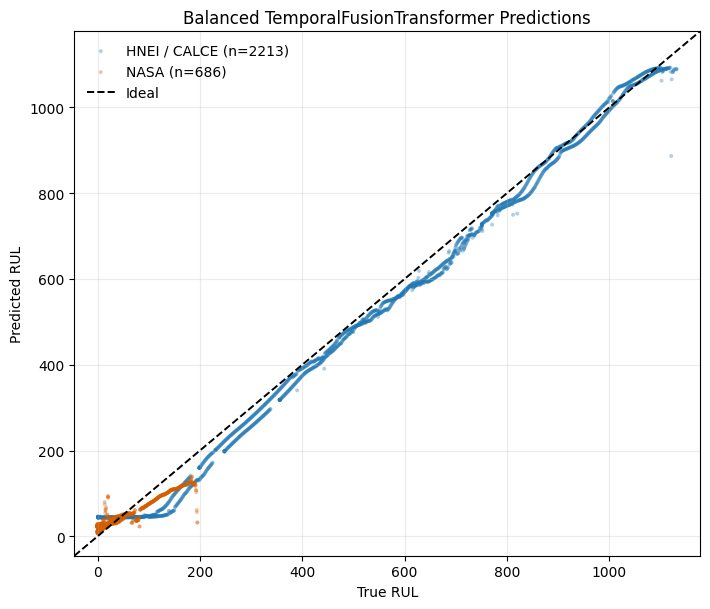

Saved plot: figures/demo_tft_transformer_balanced_pred_vs_true.png


In [46]:
PLOT_PATH.parent.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(7.2, 6.2))
colors = {"HNEI / CALCE": "#1f77b4", "NASA": "#d55e00"}
for source, color in colors.items():
    mask = prediction_df["source"] == source
    ax.scatter(
        prediction_df.loc[mask, "true_rul"],
        prediction_df.loc[mask, "predicted_rul"],
        s=8,
        alpha=0.35,
        label=f"{source} (n={mask.sum()})",
        color=color,
        edgecolors="none",
    )

lims = [
    min(prediction_df["true_rul"].min(), prediction_df["predicted_rul"].min()),
    max(prediction_df["true_rul"].max(), prediction_df["predicted_rul"].max()),
]
pad = (lims[1] - lims[0]) * 0.04
lims = [lims[0] - pad, lims[1] + pad]
ax.plot(lims, lims, linestyle="--", linewidth=1.4, color="black", label="Ideal")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel("True RUL")
ax.set_ylabel("Predicted RUL")
ax.set_title("Balanced TemporalFusionTransformer Predictions")
ax.grid(alpha=0.25)
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(PLOT_PATH, dpi=200)
plt.show()

print("Saved plot:", PLOT_PATH)
